employee retention dataset: https://www.kaggle.com/giripujar/hr-analytics. 


## 📌 Problem Statement

The objective of this project is to understand and predict employee attrition using HR analytics data. The study focuses on identifying critical factors—such as satisfaction level, salary, department, and workload—that contribute to employee turnover.

By performing exploratory data analysis (EDA) and building a Logistic Regression model, the project aims to provide insights into workforce behavior and develop a predictive system to estimate the likelihood of an employee leaving the organization.

In [29]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
%matplotlib inline

In [30]:

import seaborn as sns
df = pd.read_csv("HR_comma_sep.csv")
df.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [31]:

df.nunique()


satisfaction_level        92
last_evaluation           65
number_project             6
average_montly_hours     215
time_spend_company         8
Work_accident              2
left                       2
promotion_last_5years      2
Department                10
salary                     3
dtype: int64

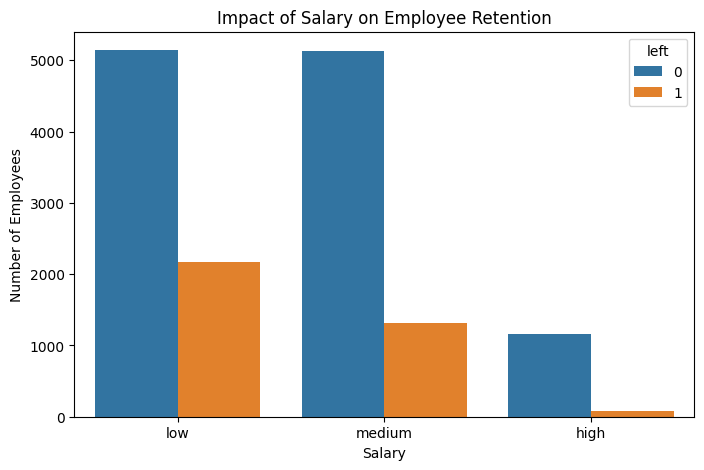

In [32]:
plt.figure(figsize=(8, 5))
sns.countplot(x="salary", hue="left", data=df)
plt.title("Impact of Salary on Employee Retention")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.show()


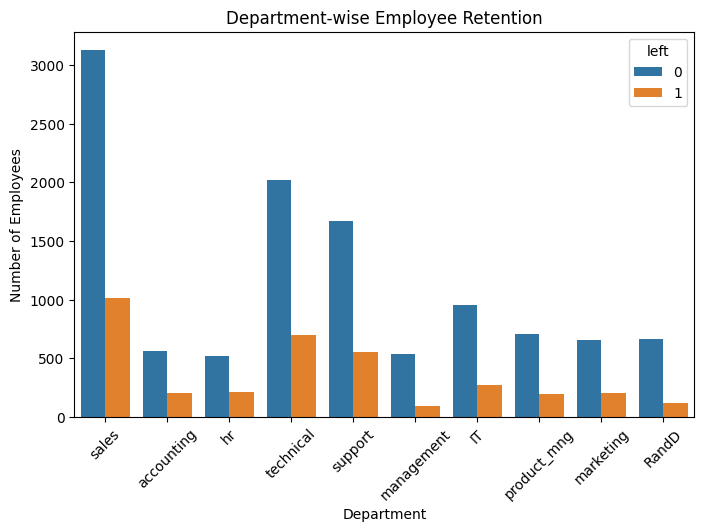

In [33]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Department", hue="left", data=df)
plt.xticks(rotation=45)
plt.title("Department-wise Employee Retention")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.show()


In [34]:
df = pd.get_dummies(df, columns=["salary", "Department"], drop_first=True)
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary_low,salary_medium,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,0.38,0.53,2,157,3,0,1,0,True,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,False,True,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,False,True,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,True,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,True,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,True,False,False,False,False,False,False,False,False,True,False
14995,0.37,0.48,2,160,3,0,1,0,True,False,False,False,False,False,False,False,False,True,False
14996,0.37,0.53,2,143,3,0,1,0,True,False,False,False,False,False,False,False,False,True,False
14997,0.11,0.96,6,280,4,0,1,0,True,False,False,False,False,False,False,False,False,True,False


In [35]:
print(df.columns)


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'salary_low', 'salary_medium',
       'Department_RandD', 'Department_accounting', 'Department_hr',
       'Department_management', 'Department_marketing',
       'Department_product_mng', 'Department_sales', 'Department_support',
       'Department_technical'],
      dtype='object')


In [36]:
X = df.drop("left", axis=1)
y = df["left"]


In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = LogisticRegression()
model.fit(X_train, y_train)

c:\Users\manol\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [39]:
y_pred = model.predict(X_test)

In [40]:
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[2113,  181],
       [ 434,  272]])

In [41]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      2294
           1       0.60      0.39      0.47       706

    accuracy                           0.80      3000
   macro avg       0.72      0.65      0.67      3000
weighted avg       0.78      0.80      0.78      3000



In [42]:
accuracy = accuracy_score(y_test, y_pred)
print(f"The accuracy of the linear regression model is {accuracy*100}%.")

The accuracy of the linear regression model is 79.5%.


## 📌 Conclusion

In this project, we analyzed employee retention using HR analytics data and identified key factors influencing employee attrition. Exploratory Data Analysis (EDA) revealed that variables such as satisfaction level, salary, and workload have a significant impact on whether employees leave the organization.

A Logistic Regression model was developed to predict employee attrition, achieving an accuracy of approximately 79.5%. While the model performs reasonably well in predicting employees who stay, it shows relatively lower performance in identifying employees who leave, indicating scope for improvement.

Overall, this study demonstrates how data-driven approaches can help organizations understand employee behavior and take proactive measures to improve retention. Future work can include using advanced models, feature selection techniques, and class imbalance handling to enhance prediction performance.